In [1]:
import polars as pl
from itertools import chain
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
anos_egdi = list(chain(range(2003, 2006), range(2008, 2025, 2)))
print(anos_egdi)

[2003, 2004, 2005, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]


In [3]:
dfs = [pl.read_csv(f'EGOV_DATA_{ano}.csv') for ano in anos_egdi]

In [4]:
dfs

[shape: (193, 8)
 ┌────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┐
 │ Survey ┆ Country    ┆ E-Governme ┆ E-Governme ┆ E-Particip ┆ Online     ┆ Human      ┆ Telecommu │
 │ Year   ┆ Name       ┆ nt Rank    ┆ nt Index   ┆ ation      ┆ Service    ┆ Capital    ┆ nication  │
 │ ---    ┆ ---        ┆ ---        ┆ ---        ┆ Index      ┆ Index      ┆ Index      ┆ Infrastru │
 │ i64    ┆ str        ┆ i64        ┆ f64        ┆ ---        ┆ ---        ┆ ---        ┆ ctu…      │
 │        ┆            ┆            ┆            ┆ f64        ┆ f64        ┆ f64        ┆ ---       │
 │        ┆            ┆            ┆            ┆            ┆            ┆            ┆ f64       │
 ╞════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╡
 │ 2003   ┆ Iraq       ┆ 174        ┆ 0.0        ┆ 0.0        ┆ 0.0        ┆ 0.93       ┆ 0.01578   │
 │ 2003   ┆ Ireland    ┆ 17         ┆ 0.69651    ┆ 0.5862     ┆ 0

In [5]:
df_inicial = (
    pl.concat(dfs)
    .drop('E-Government Rank')
    .rename({
        'Survey Year': 'ano',
        'Country Name': 'pais',
        'E-Government Index': 'egdi',
        'E-Participation Index': 'epi',
        'Online Service Index': 'osi',
        'Human Capital Index': 'hci',
        'Telecommunication Infrastructure Index': 'tii'
    })
    .with_columns(
        pl.col(pl.Float64).round(2),
        pl.col('pais').str.replace(" ", "")
    )
    .sort('ano')
)

In [6]:
df_inicial.head()

ano,pais,egdi,epi,osi,hci,tii
i64,str,f64,f64,f64,f64,f64
2003,"""Iraq""",0.0,0.0,0.0,0.93,0.02
2003,"""Ireland""",0.7,0.59,0.62,0.96,0.51
2003,"""Israel""",0.66,0.4,0.63,0.91,0.45
2003,"""Italy""",0.68,0.47,0.62,0.94,0.5
2003,"""Jamaica""",0.43,0.16,0.38,0.79,0.13


In [7]:
df_inicial.shape

(2316, 7)

In [8]:
df_brasil = (
    df_inicial.filter(
        pl.col('pais') == 'Brazil'
    )
    .drop('pais')
)

In [9]:
df_brasil.head()

ano,egdi,epi,osi,hci,tii
i64,f64,f64,f64,f64,f64
2003,0.53,0.38,0.58,0.83,0.17
2004,0.57,0.25,0.64,0.9,0.17
2005,0.6,0.49,0.75,0.88,0.16
2008,0.57,0.45,0.6,0.88,0.22
2010,0.5,0.29,0.37,0.88,0.25


In [10]:
f64_cols = df_brasil.select(
    pl.col(pl.Float64)
).columns
print(f64_cols)

['egdi', 'epi', 'osi', 'hci', 'tii']


In [11]:
df_brasil_unpivoted = df_brasil.unpivot(
    on=f64_cols,
    index='ano',
    variable_name='indice',
    value_name='valor'
)

In [12]:
df_brasil_unpivoted.head()

ano,indice,valor
i64,str,f64
2003,"""egdi""",0.53
2004,"""egdi""",0.57
2005,"""egdi""",0.6
2008,"""egdi""",0.57
2010,"""egdi""",0.5


In [13]:
df_brasil_unpivoted_egdi = df_brasil_unpivoted.filter(
    pl.col('indice') == 'egdi'
)

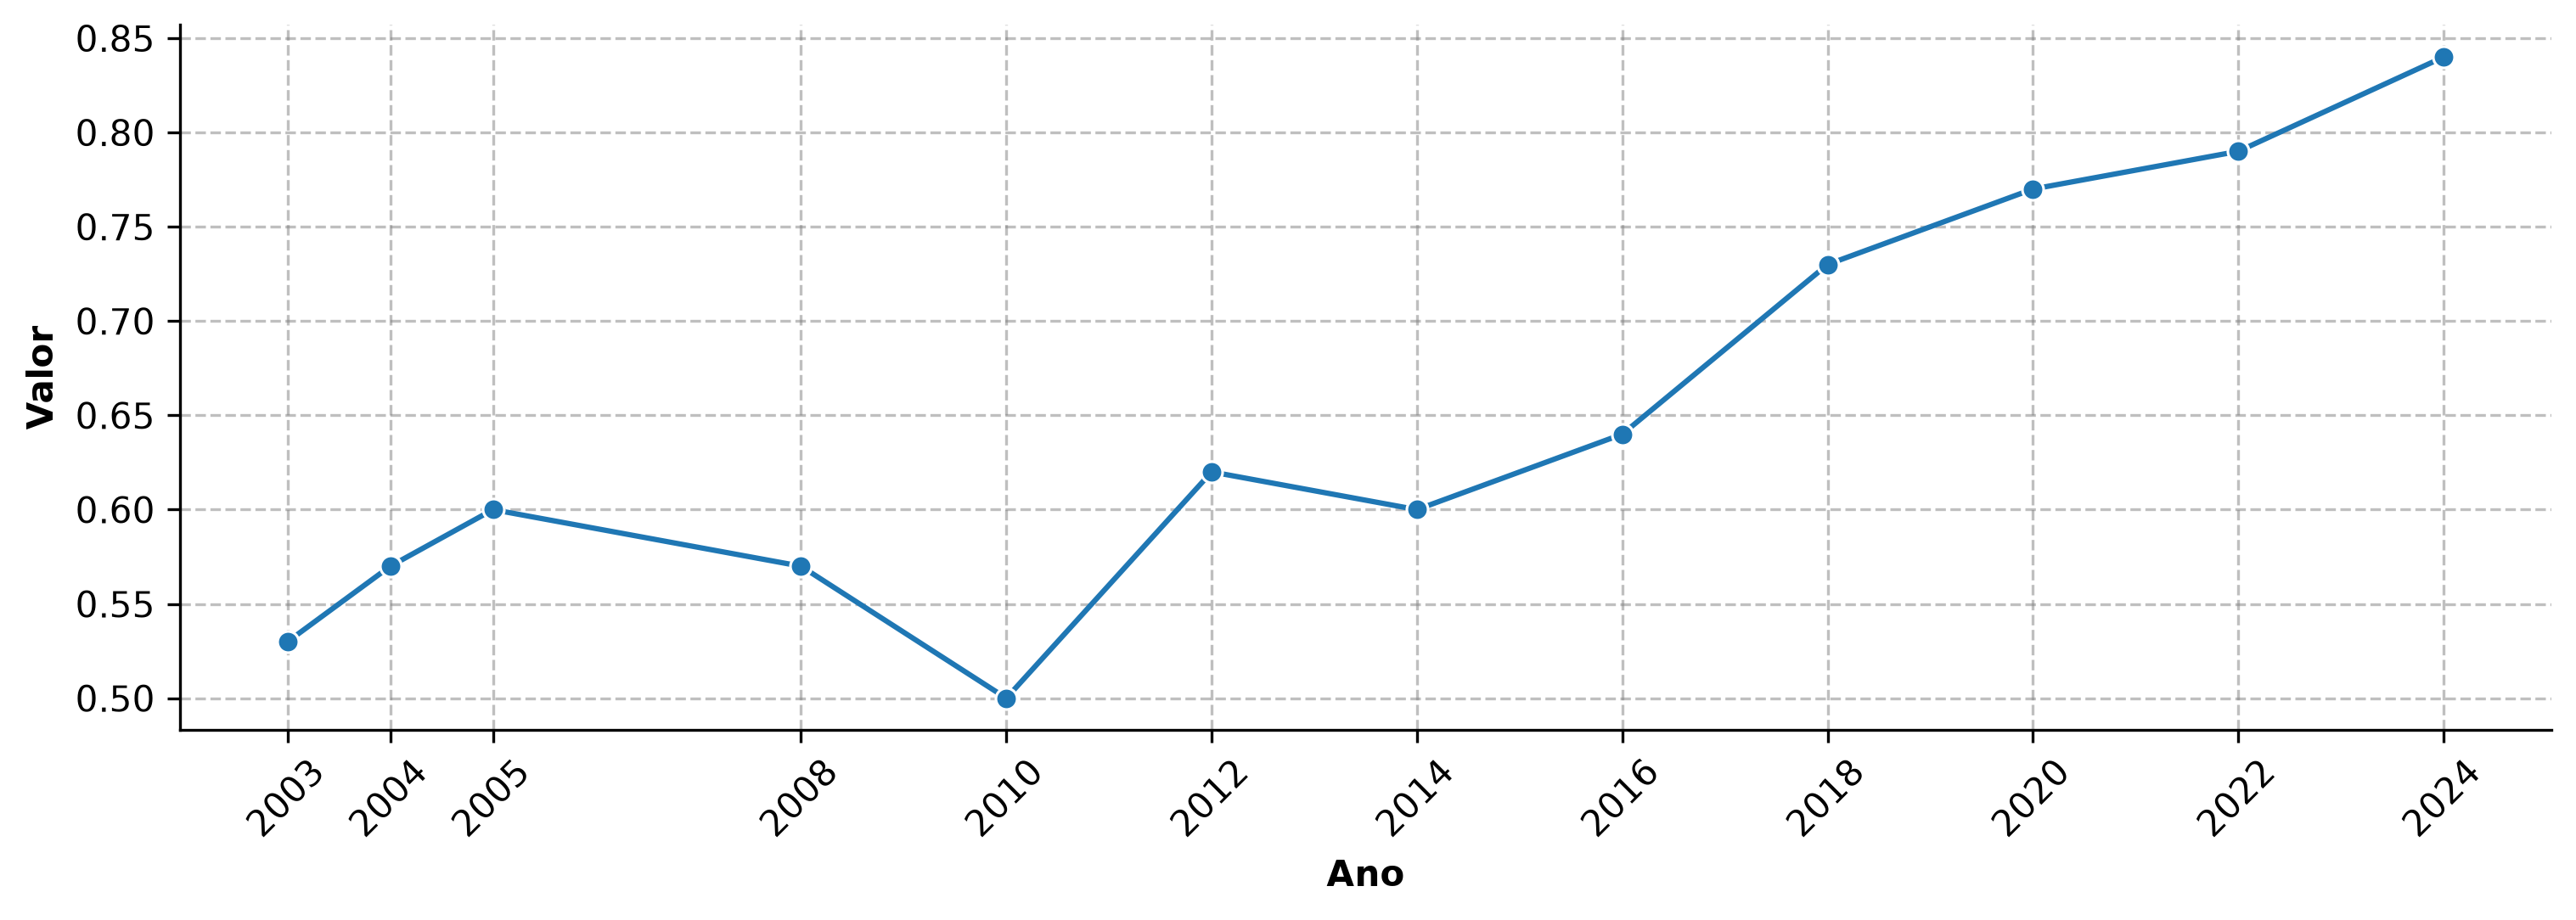

In [35]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

sns.lineplot(
    df_brasil_unpivoted_egdi,
    x='ano',
    y='valor',
    marker='o'
)

ax.set_xticks(anos_egdi, labels=anos_egdi, rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='grey', linestyle='--', alpha=0.5)
ax.set_ylabel('Valor', fontweight='bold')
ax.set_xlabel('Ano', fontweight='bold')

fig.savefig('egdi_brasil_egdi', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
df_brasil_unpivoted_epi = df_brasil_unpivoted.filter(
    pl.col('indice') == 'epi'
)

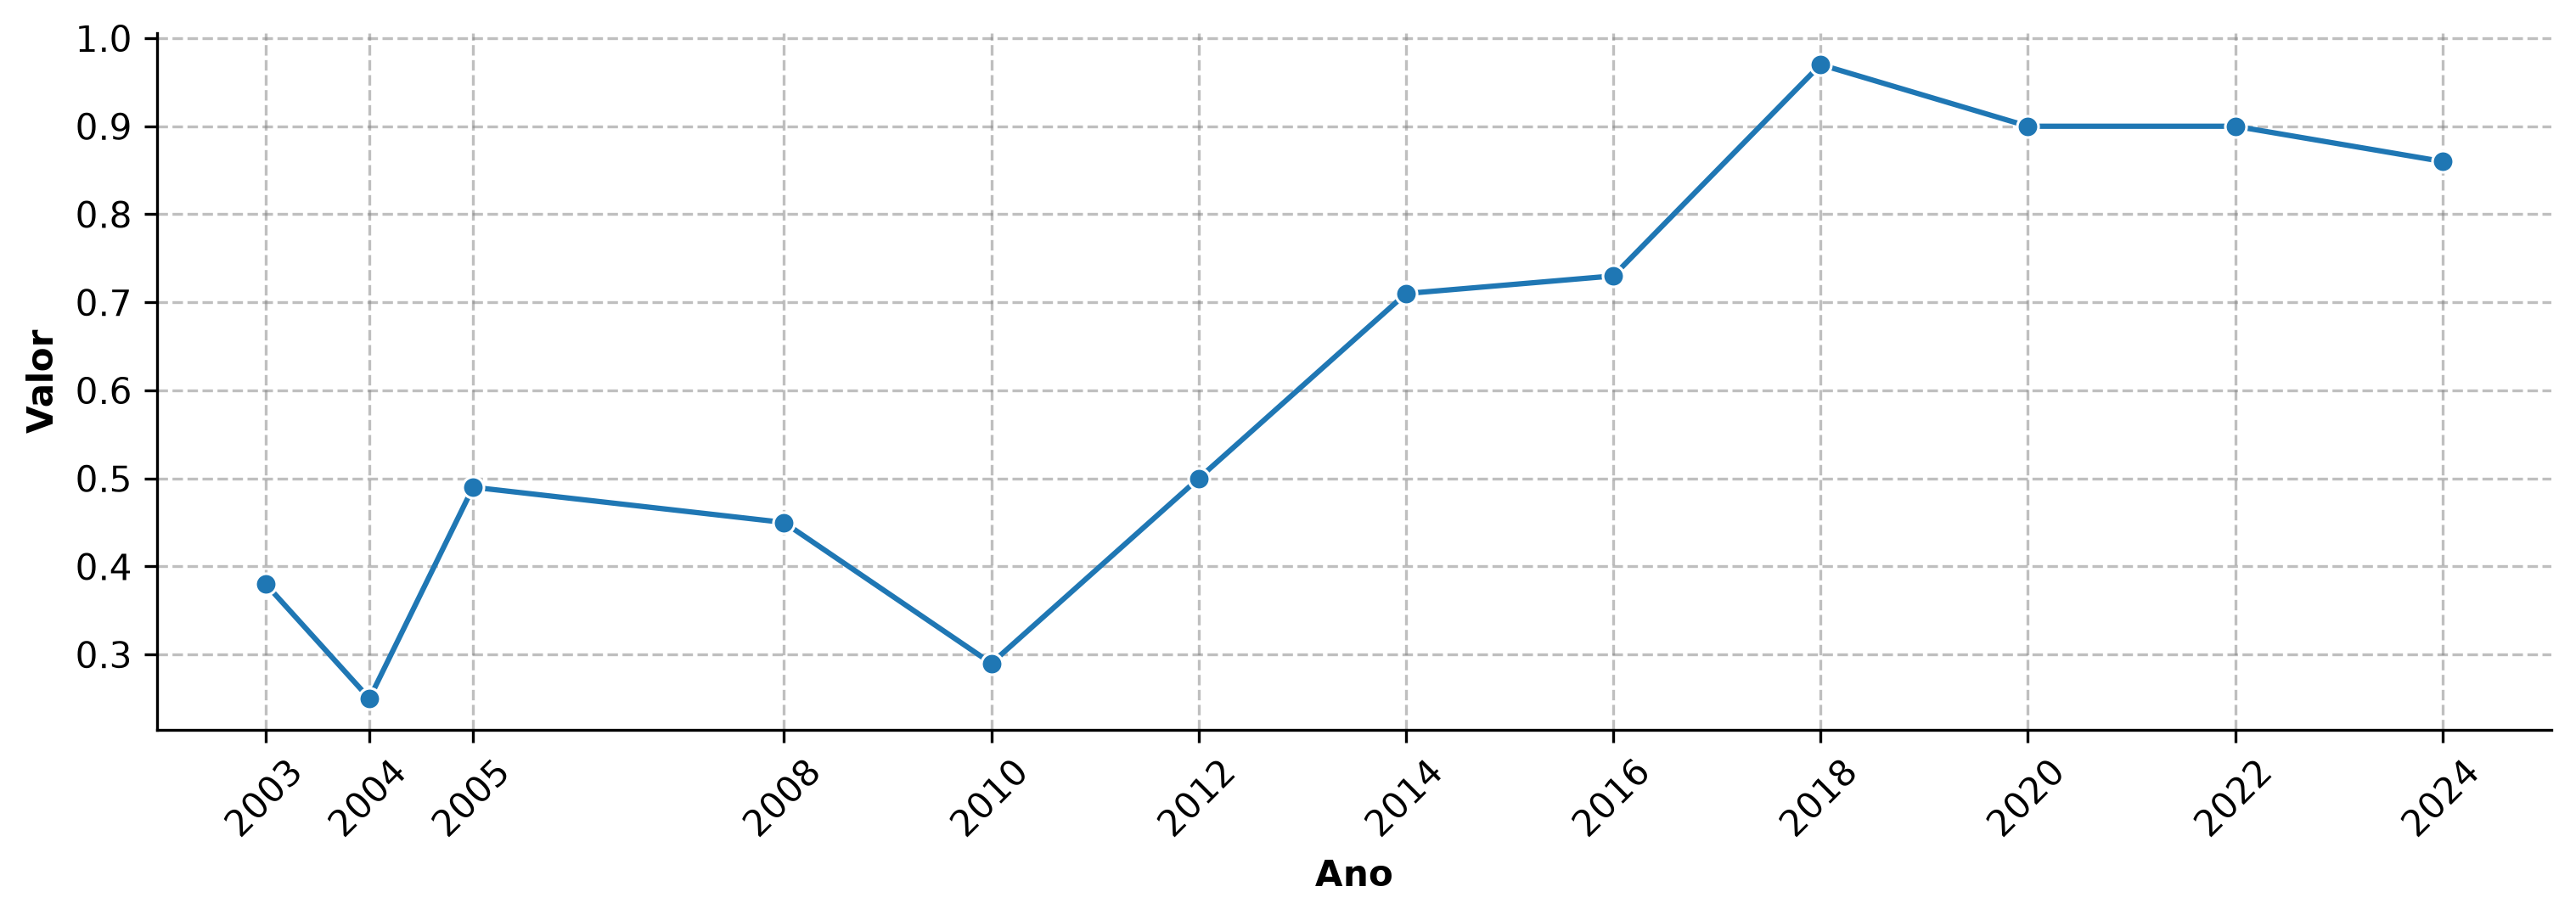

In [33]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

sns.lineplot(
    df_brasil_unpivoted_epi,
    x='ano',
    y='valor',
    marker='o'
)

ax.set_xticks(anos_egdi, labels=anos_egdi, rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='grey', linestyle='--', alpha=0.5)
ax.set_ylabel('Valor', fontweight='bold')
ax.set_xlabel('Ano', fontweight='bold')

fig.savefig('egdi_brasil_epi', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
df_brasil_unpivoted_subindices = (
    df_brasil_unpivoted.filter(
        ~pl.col('indice').is_in(['egdi', 'epi'])
    )
    .with_columns(
        pl.col('indice').str.to_uppercase()
    )
)

In [22]:
df_brasil_unpivoted_subindices.head()

ano,indice,valor
i64,str,f64
2003,"""OSI""",0.58
2004,"""OSI""",0.64
2005,"""OSI""",0.75
2008,"""OSI""",0.6
2010,"""OSI""",0.37


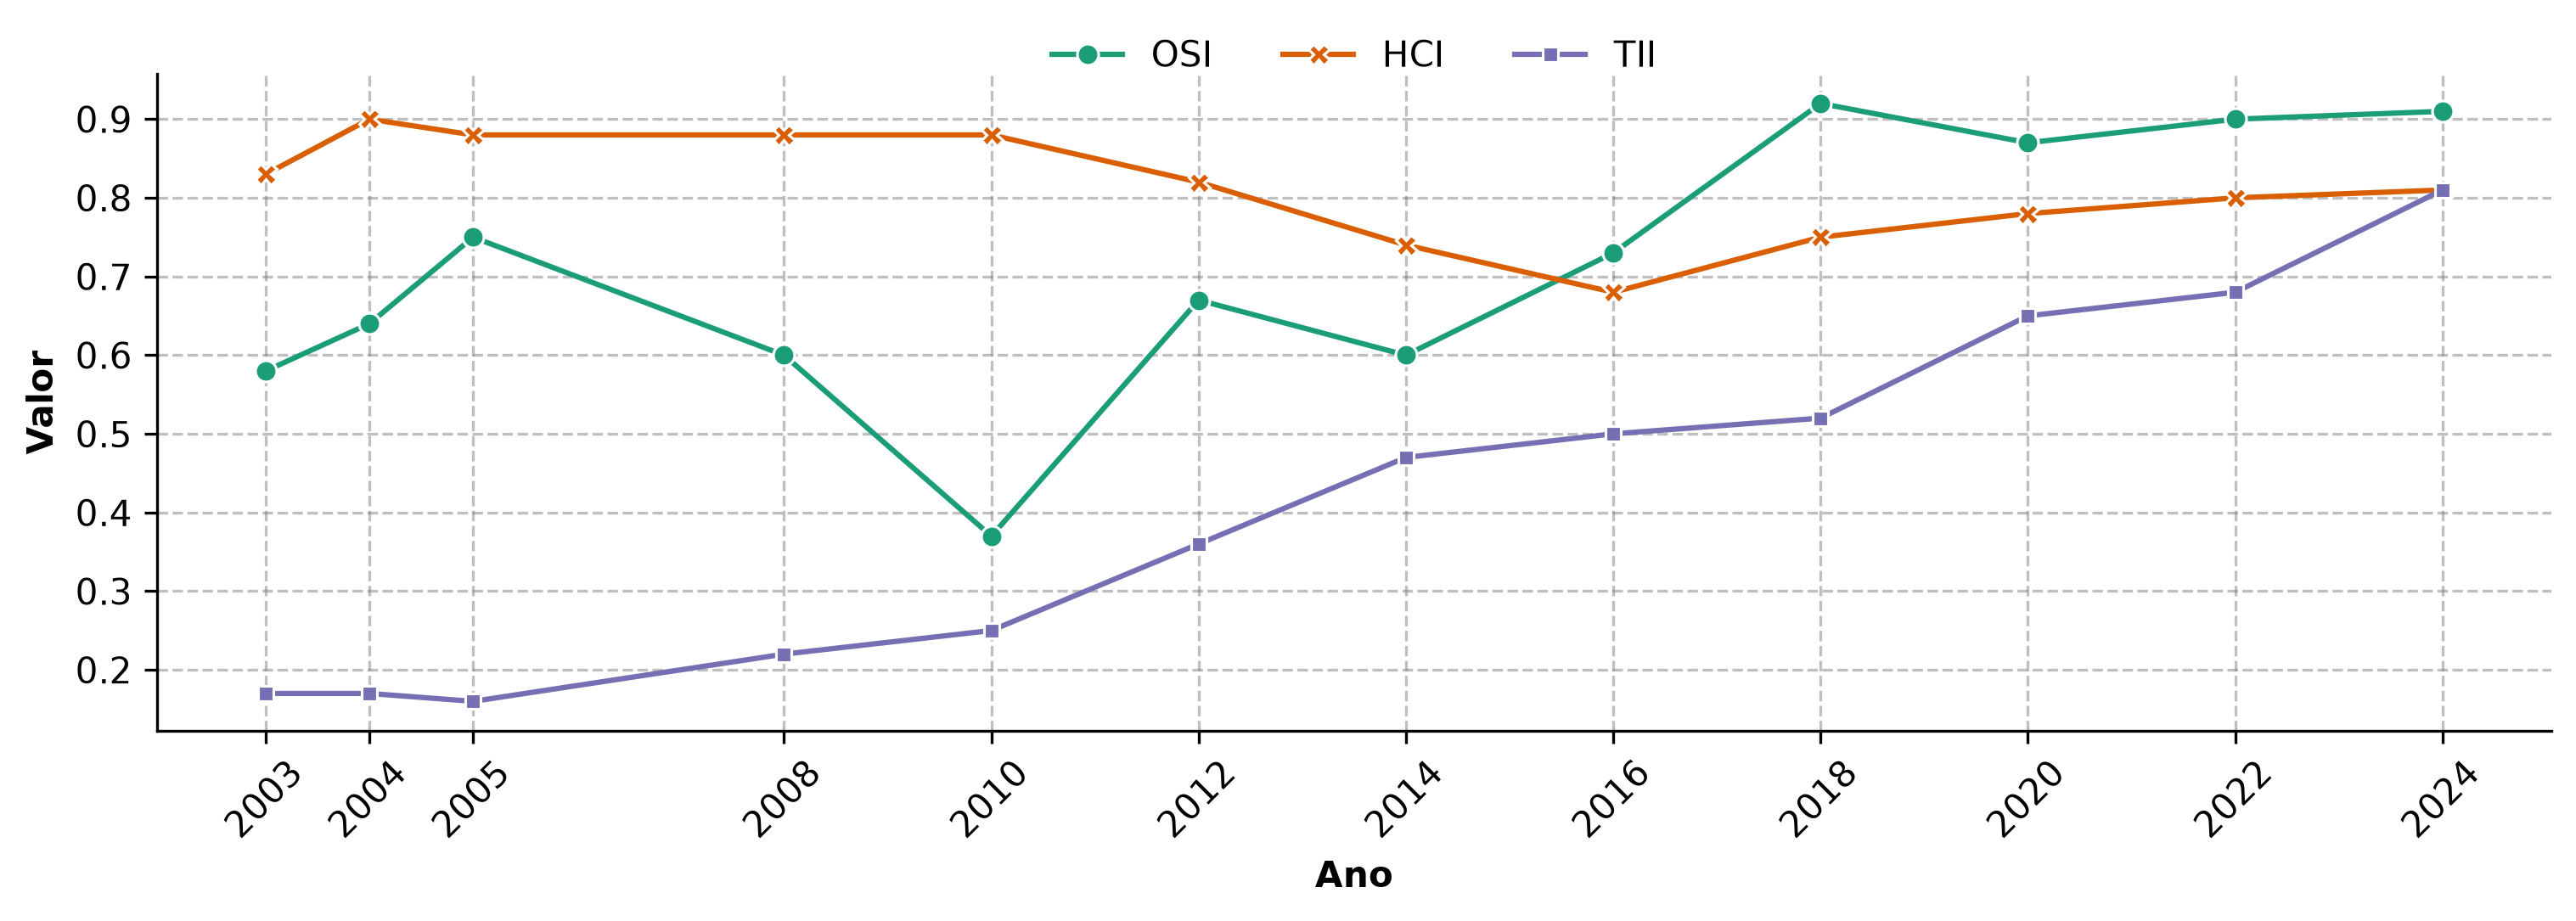

In [32]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

sns.lineplot(
    df_brasil_unpivoted_subindices,
    x='ano',
    y='valor',
    hue='indice',
    style='indice',
    dashes=None,
    markers=True,
    palette='Dark2'
)

ax.set_xticks(anos_egdi, labels=anos_egdi, rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='grey', linestyle='--', alpha=0.5)
ax.set_ylabel('Valor', fontweight='bold')
ax.set_xlabel('Ano', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=3, frameon=False)

fig.savefig('egdi_brasil_subindices', dpi=300, bbox_inches='tight')
plt.show()